In [28]:
import numpy as np
import pandas as pd
import seaborn
import matplotlib.pyplot as plt


path= '/Users/user/Dev/ml/w4/diabetes/'
db12_full= path+'diabetes_012_health_indicators_BRFSS2015.csv'
db5050_binar= path+'diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
db12_binar= path+'diabetes_binary_health_indicators_BRFSS2015.csv'

df_full_012=pd.read_csv(db12_full)
df_full_012.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


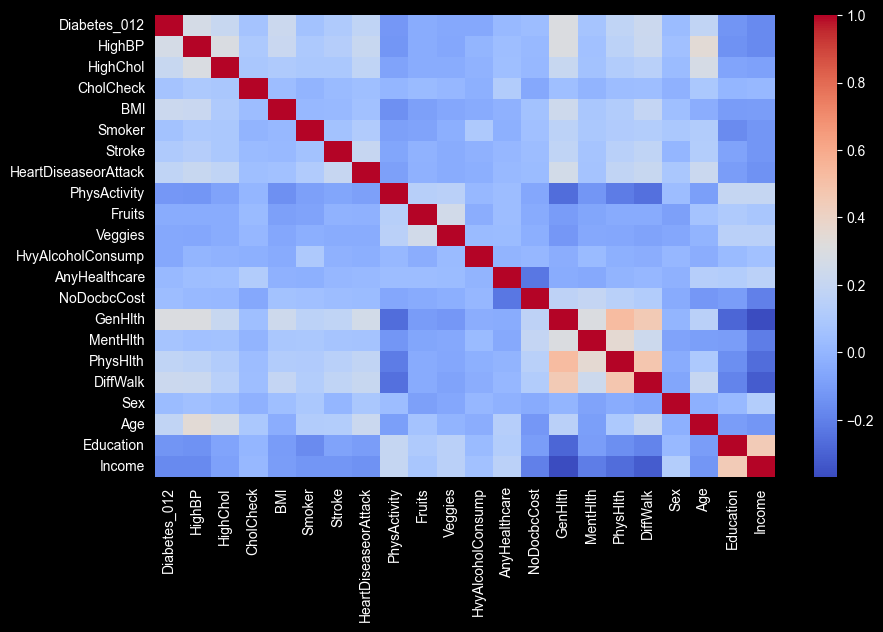

In [29]:
corr= df_full_012.corr(numeric_only=True)
plt.figure(figsize=(10,6))
seaborn.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()

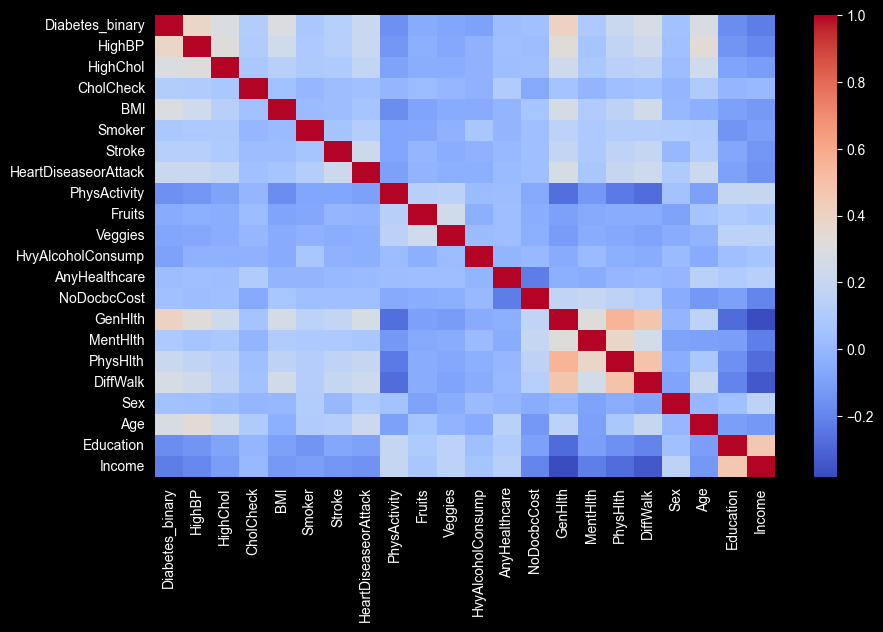

In [30]:
df_5050_01=pd.read_csv(db5050_binar)
corr= df_5050_01.corr(numeric_only=True)
plt.figure(figsize=(10,6))
seaborn.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()

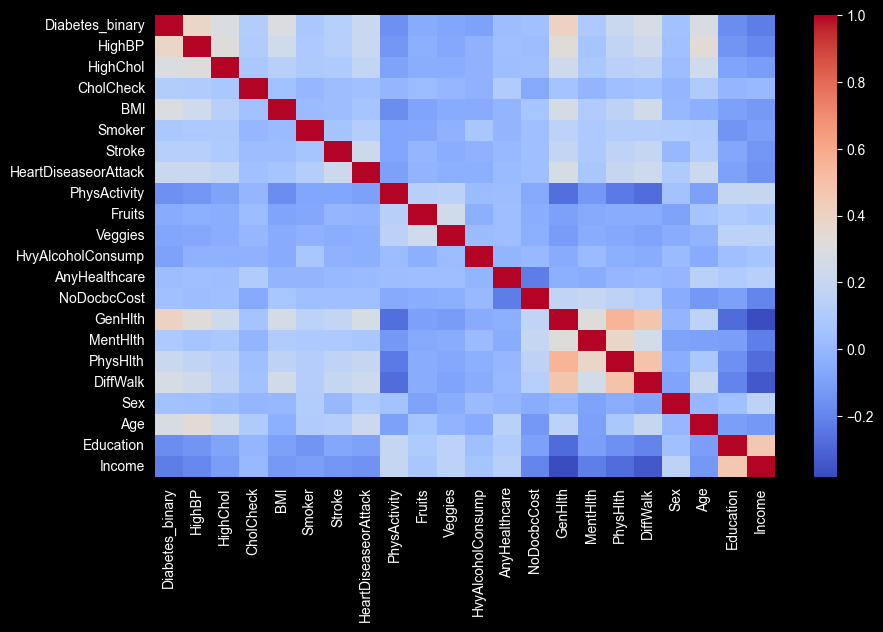

In [31]:
df_full_01=pd.read_csv(db12_binar)
corr= df_5050_01.corr(numeric_only=True)
plt.figure(figsize=(10,6))
seaborn.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()

In [32]:
def corr_comp(dataframes: dict, targets: dict, method='spearman'):
    '''
        Compare correlations from several DataFrames against their own target.
        Parameters:
            dataframes: dict  {'name': DataFrame}
            targets: dict  {'name': 'target_column'}
            method: str   'spearman' (default) or 'pearson'
    '''
    corr_res= {}
    for name, df in dataframes.items():
        target= targets[name]
        corr= df.corr(method= method, numeric_only=True)[target].drop(target).to_frame(name=name)
        corr_res[name]= corr

    # Unir en una sola tabla por variables (índice común)
    corr_tbl = pd.concat(corr_res.values(), axis=1)
    corr_tbl.columns = [f'{name}\n({targets[name]})' for name in corr_res]
    corr_tbl = corr_tbl.sort_values(by=corr_tbl.columns[0], ascending=True)

    return corr_tbl

dataframes= {'df_12': df_full_012, 'df5050': df_5050_01, 'df_binar': df_full_01}
targets= {'df_12': 'Diabetes_012', 'df5050': 'Diabetes_binary', 'df_binar': 'Diabetes_binary'}
correlation= corr_comp(dataframes, targets)
display(correlation)

,df_12\n(Diabetes_012),df5050\n(Diabetes_binary),df_binar\n(Diabetes_binary)
Income,-0.172611,-0.232529,-0.163305
Education,-0.126862,-0.169926,-0.120038
PhysActivity,-0.121988,-0.158666,-0.118133
Veggies,-0.059353,-0.079293,-0.056584
HvyAlcoholConsump,-0.057244,-0.094853,-0.057056
Fruits,-0.042268,-0.054077,-0.040779
AnyHealthcare,0.014530,0.023191,0.016255
Sex,0.030143,0.044413,0.031430
NoDocbcCost,0.037379,0.040977,0.031433
MentHlth,0.044921,0.056515,0.040049
